# Customer Trends & Diagnostics EDA

This notebook is split from `02_customer_behavior.ipynb` for maintainability.


## Notebook Roadmap

1. Data Setup & KPI Baseline
2. Bivariate Behavior Comparison
3. Time-slot Pattern (Day x Hour)
4. Customer Segmentation (User-level)
5. Segment Preferences (Product / Aisle)
6. Retention & Churn
7. Basket Value by Category
8. CLV Trends & Segment CLV
9. Extra Diagnostics (Funnel / Gateway / Trend / Histogram)
10. Executive Summary

Run guide:
- ตั้งค่า `USE_SAMPLE` ที่ cell โหลดข้อมูล
- รันจากบนลงล่างเพื่อให้ตัวแปรกลาง (เช่น `rfm`, `segment_txn`, `customer_monthly`) พร้อมใช้งานครบ

In [1]:
import importlib
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# --- Display formatting (readable numbers in notebook output) ---
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

# --- Notebook output controls (clean vs verbose mode) ---
SHOW_VERBOSE_TABLES = False
PREVIEW_ROWS = 10

def show_df(df, title=None, n=PREVIEW_ROWS):
    """Display full table only in verbose mode; otherwise show top-N preview."""
    if title:
        print(title)
    display(df if SHOW_VERBOSE_TABLES else df.head(n))

# --- Configuration ---
# set USE_SAMPLE = True for quick testing, False for full dataset analysis
USE_SAMPLE = False

# Setup project path
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "src").exists() and (parent / "data").exists():
            PROJECT_ROOT = parent
            break

if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

# Reload the loader module so notebook execution always uses the latest code.
import instacart_quality.data_access as data_access_module
importlib.reload(data_access_module)

df = data_access_module.load_customer_behavior_data(
    use_sample=USE_SAMPLE,
    project_root=PROJECT_ROOT,
)

print(f"Loaded {len(df):,} records with {df['user_id'].nunique():,} unique customers")
print(f"Date range: {df['order_date'].min().date()} to {df['order_date'].max().date()}")
print(f"Data mode: {'SAMPLE' if USE_SAMPLE else 'FULL DATASET'}")
print(f"Columns: {list(df.columns)}\n")
df.head()

Loaded 32,434,489 records with 206,209 unique customers
Date range: 2014-07-01 to 2015-07-01
Data mode: FULL DATASET
Columns: ['order_id', 'product_id', 'add_to_cart_order', 'reordered', 'user_id', 'eval_set', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order', 'cumulative_days', 'order_date', 'product_name', 'total_price', 'cumulative_reorder_per_customer']



,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,cumulative_days,order_date,product_name,total_price,cumulative_reorder_per_customer
0,2539329,196,1,0,1,prior,1,2,8,0.0,0.0,2015-07-01,Soda,1,0
1,2539329,14084,2,0,1,prior,1,2,8,0.0,0.0,2015-07-01,Organic Unsweetened Vanilla Almond Milk,1,0
2,2539329,12427,3,0,1,prior,1,2,8,0.0,0.0,2015-07-01,Original Beef Jerky,1,0
3,2539329,26088,4,0,1,prior,1,2,8,0.0,0.0,2015-07-01,Aged White Cheddar Popcorn,1,0
4,2539329,26405,5,0,1,prior,1,2,8,0.0,0.0,2015-07-01,XL Pick-A-Size Paper Towel Rolls,1,0


## 3) Segmentation & Customer Value Lens

### 3.1 Customer Segmentation (User-level features)

สร้างกลุ่มลูกค้าจาก **User-level features** เพื่อวิเคราะห์ "ความต่าง" ของพฤติกรรมให้ชัดขึ้น

Features หลัก:
- `total_orders` = จำนวนครั้งที่สั่งซื้อ
- `avg_basket_size` = จำนวนสินค้าเฉลี่ยต่อตะกร้า
- `reorder_ratio` = อัตราการซื้อซ้ำ
- `days_since_last_order` = วันตั้งแต่สั่งครั้งล่าสุด

Logic การแบ่ง Segment (แบบเรียบง่ายและตีความง่าย):
- **Whales**: ลูกค้าที่สั่งบ่อยมาก (`total_orders` อยู่ใน Top 10%)
- **Regulars**: ลูกค้าทั่วไป
- **Churned**: ลูกค้าที่ไม่ได้สั่งมานานเกิน 30 วัน

หมายเหตุ: ถ้าลูกค้าเข้าเงื่อนไข Churned จะถูกจัดเป็น `Churned` แม้จะเคยสั่งบ่อย (override เพื่อเน้นสถานะล่าสุด)

#### 3.2 Segment Distribution Check

In [2]:
snapshot_date = df["order_date"].max() + pd.Timedelta(days=1)

# 1) Order frequency + reorder behavior + recency per user
user_order_profile = (
    df.groupby("user_id", observed=False)
    .agg(
        total_orders=("order_id", "nunique"),
        reorder_ratio=("reordered", "mean"),
        last_order_date=("order_date", "max"),
    )
    .reset_index()
)

# 2) Basket size per order -> average basket size at user level
order_basket = (
    df.groupby(["user_id", "order_id"], observed=False)
    .agg(basket_size=("product_id", "count"))
    .reset_index()
)

user_basket_profile = (
    order_basket.groupby("user_id", observed=False)
    .agg(avg_basket_size=("basket_size", "mean"))
    .reset_index()
)

# Keep variable name `rfm` for downstream compatibility in this notebook.
rfm = user_order_profile.merge(user_basket_profile, on="user_id", how="left")
rfm["days_since_last_order"] = (snapshot_date - rfm["last_order_date"]).dt.days

# Segment rules
whale_threshold = rfm["total_orders"].quantile(0.90)
rfm["segment"] = "Regulars"
rfm.loc[rfm["total_orders"] >= whale_threshold, "segment"] = "Whales"
rfm.loc[rfm["days_since_last_order"] > 30, "segment"] = "Churned"

segment_order = ["Whales", "Regulars", "Churned"]
rfm["segment"] = pd.Categorical(rfm["segment"], categories=segment_order, ordered=True)

print(f"Whale threshold (Top 10% total_orders): {whale_threshold:,.2f}")
show_df(rfm[["user_id", "total_orders", "avg_basket_size", "reorder_ratio", "days_since_last_order", "segment"]], title="User-level segmentation sample:")

segment_summary = (
    rfm.groupby("segment", observed=False)
    .agg(
        users=("user_id", "nunique"),
        median_total_orders=("total_orders", "median"),
        median_avg_basket_size=("avg_basket_size", "median"),
        median_reorder_ratio=("reorder_ratio", "median"),
        median_days_since_last_order=("days_since_last_order", "median"),
    )
    .reset_index()
)

print("Segment summary:")
show_df(segment_summary)

Whale threshold (Top 10% total_orders): 37.00
User-level segmentation sample:


,user_id,total_orders,avg_basket_size,reorder_ratio,days_since_last_order,segment
0,1,10,5.900000,0.694915,1,Regulars
1,2,14,13.928571,0.476923,1,Regulars
2,3,12,7.333333,0.625000,1,Regulars
3,4,5,3.600000,0.055556,1,Regulars
4,5,4,9.250000,0.378378,1,Regulars
5,6,3,4.666667,0.142857,1,Regulars
6,7,20,10.300000,0.669903,1,Regulars
7,8,3,16.333333,0.265306,1,Regulars
8,9,3,25.333333,0.236842,1,Regulars
9,10,5,28.600000,0.342657,1,Regulars


Segment summary:


,segment,users,median_total_orders,median_avg_basket_size,median_reorder_ratio,median_days_since_last_order
0,Whales,20644,51.0,9.315789,0.725983,1.0
1,Regulars,185565,8.0,8.863636,0.400000,1.0
2,Churned,0,NaN,NaN,NaN,NaN


In [3]:
# เชื่อมโยง Segment กลับไปที่ Data หลัก
df = df.merge(rfm[["user_id", "segment"]], on="user_id", how="left")

# ตรวจสอบว่ารวมสำเร็จไหม
show_df(df.groupby("segment").size().to_frame("rows"), title="Rows by segment:")

Rows by segment:


,rows
segment,
Whales,11742653
Regulars,20691836


#### 3.3 Segment KPI Snapshot

#### 3.4 Segment Size & Balance

In [4]:
show_df(
    df.groupby("segment", observed=False)["order_hour_of_day"].mean().to_frame("avg_order_hour"),
    title="Average order hour by segment:",
)

Average order hour by segment:


,avg_order_hour
segment,
Whales,13.204661
Regulars,13.550007
Churned,NaN


#### 3.5 Segment Spend Sanity Check

In [5]:
# ดูสินค้า Top 3 ของแต่ละ Segment
rows = []
for seg in segment_order:
    top_prods = (
        df[df["segment"] == seg]["product_name"]
        .value_counts()
        .head(3)
        .rename("order_lines")
        .reset_index()
        .rename(columns={"index": "product_name"})
    )
    top_prods["segment"] = seg
    rows.append(top_prods)

top3_by_segment = pd.concat(rows, ignore_index=True)
show_df(top3_by_segment[["segment", "product_name", "order_lines"]], title="Top 3 products by segment:")

Top 3 products by segment:


,segment,product_name,order_lines
0,Whales,Banana,177706
1,Whales,Bag of Organic Bananas,163218
2,Whales,Organic Strawberries,117817
3,Regulars,Banana,294859
4,Regulars,Bag of Organic Bananas,216232
5,Regulars,Organic Baby Spinach,151371


#### 3.6 Segment Product Breadth

<Axes: xlabel='order_dow', ylabel='segment'>

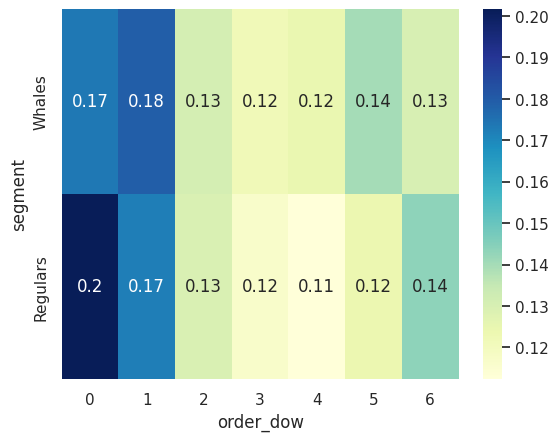

In [6]:
# กลุ่มไหนสั่งวันเสาร์-อาทิตย์ เยอะกว่ากัน?
day_dist = pd.crosstab(df['segment'], df['order_dow'], normalize='index')
# แสดงผลเป็น Heatmap จะดูง่ายมาก
import seaborn as sns
sns.heatmap(day_dist, annot=True, cmap="YlGnBu")

### 3.7 Product Preferences by Segment
ใช้ transaction-level data ที่ join กับ segment จากตาราง user-level เพื่ออ่านพฤติกรรมสินค้าอย่างถูกบริบท

ตีความเชิงธุรกิจจากความชอบสินค้าแต่ละ segment

- Whales: สินค้า/หมวดหมู่ที่สั่งบ่อยและมีสัดส่วนสูง
- Regulars: สินค้าฐานกว้างที่สร้าง volume
- Churned: หมวดหมู่ที่อาจใช้ทำ win-back campaign

Use case:
- Recommendation
- Merchandising
- Segment-specific Marketing

#### 3.8 Segment Preference Charts

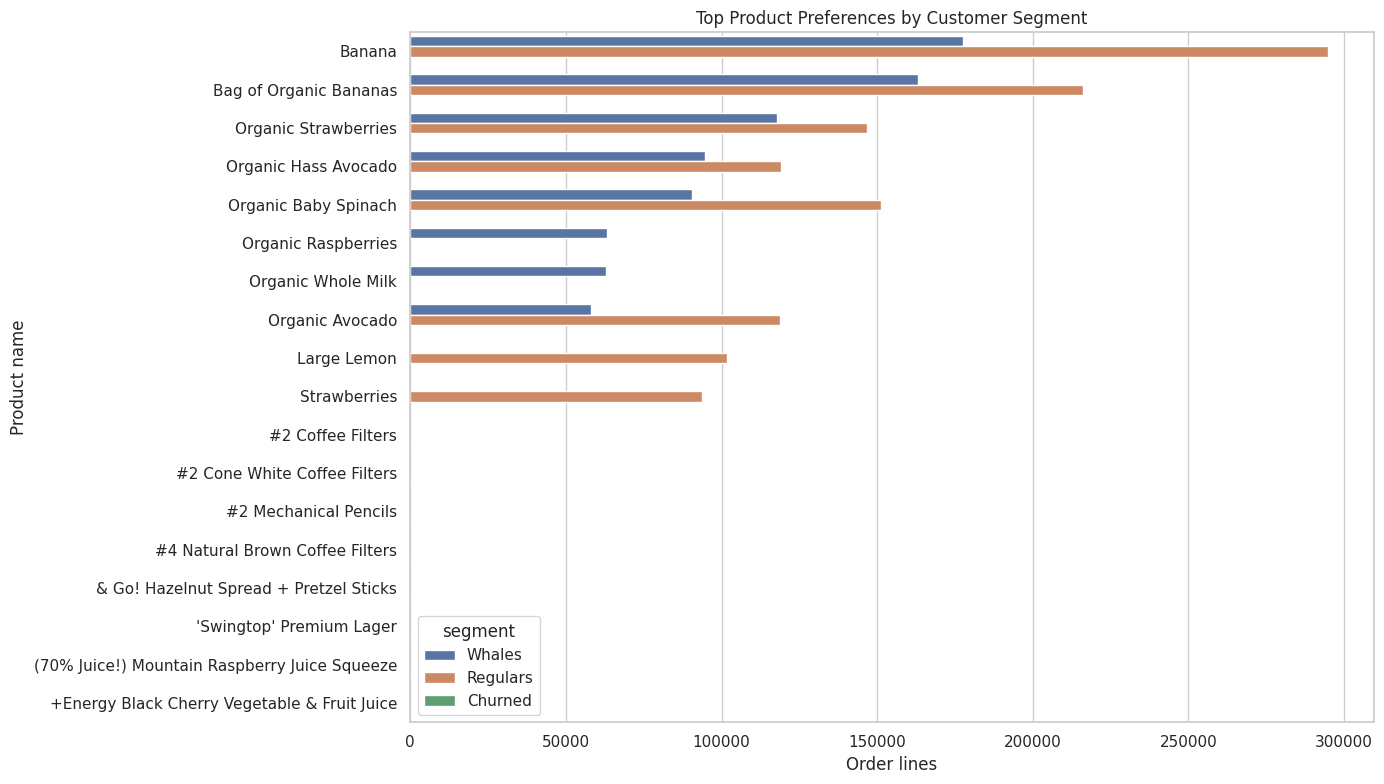

Top products by segment:


,segment,product_name,order_lines
0,Whales,Banana,177706
1,Whales,Bag of Organic Bananas,163218
2,Whales,Organic Strawberries,117817
3,Whales,Organic Hass Avocado,94605
4,Whales,Organic Baby Spinach,90550
5,Whales,Organic Raspberries,63262
6,Whales,Organic Whole Milk,63003
7,Whales,Organic Avocado,58081
8,Regulars,Banana,294859
9,Regulars,Bag of Organic Bananas,216232


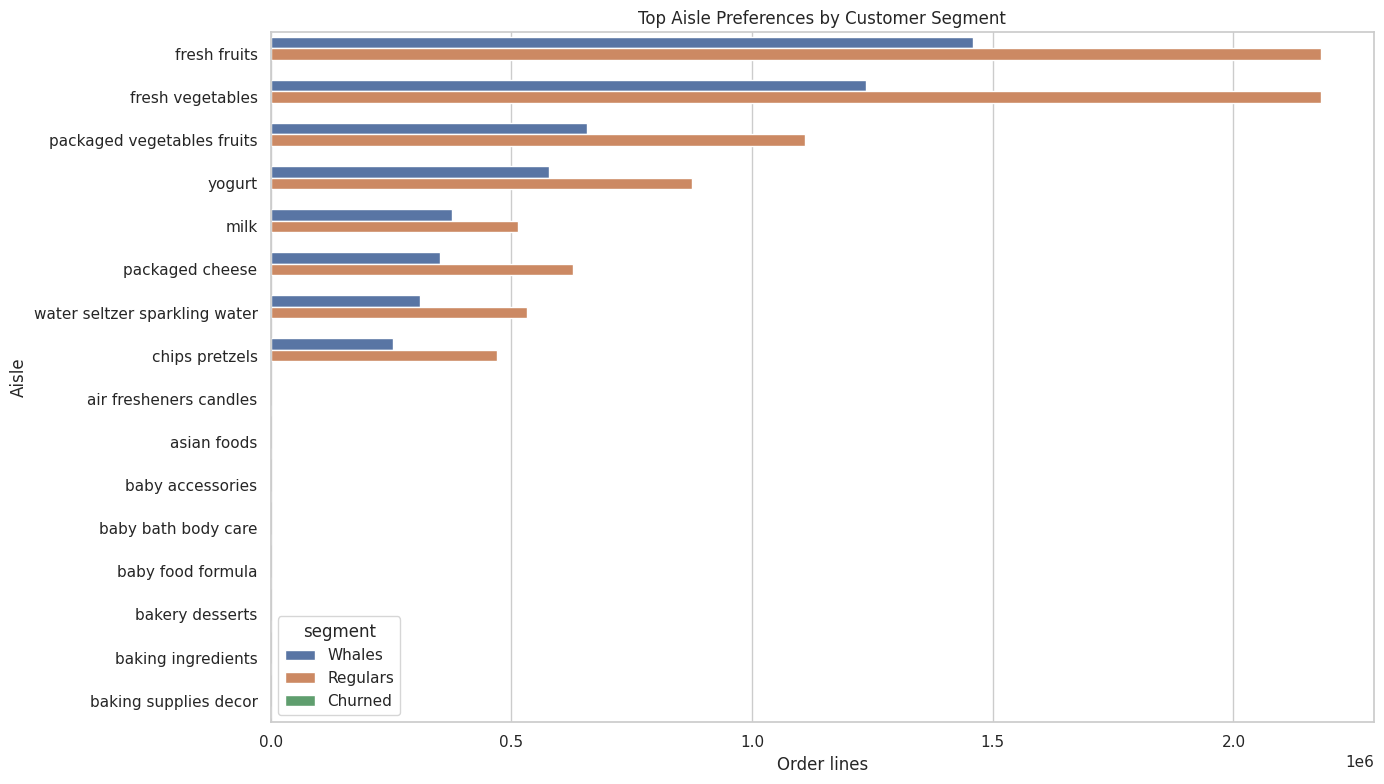

Top aisles by segment:


,segment,aisle,order_lines
0,Whales,fresh fruits,1459398
1,Whales,fresh vegetables,1237018
2,Whales,packaged vegetables fruits,656049
3,Whales,yogurt,577780
4,Whales,milk,377380
5,Whales,packaged cheese,352526
6,Whales,water seltzer sparkling water,309860
7,Whales,chips pretzels,253093
8,Regulars,fresh fruits,2182790
9,Regulars,fresh vegetables,2181003


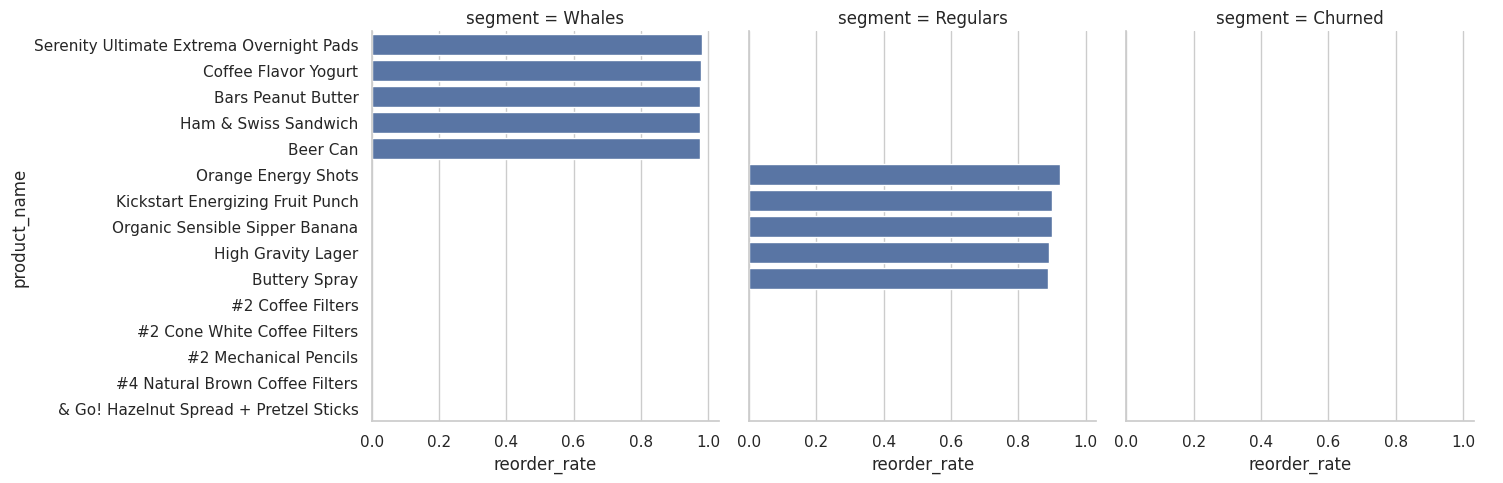

Median reorder_rate by segment:


,median_reorder_rate
segment,
Whales,0.97619
Regulars,0.90000
Churned,NaN


In [7]:
segment_txn = df.copy()

# Use existing segment if already merged into df; otherwise bring from rfm.
if "segment" not in segment_txn.columns:
    segment_txn = segment_txn.merge(
        rfm[["user_id", "segment"]],
        on="user_id",
        how="left",
    )

# Ensure aisle exists for aisle-level preference analysis.
if "aisle" not in segment_txn.columns:
    product_dim = data_access_module.load_product_dimension(
        use_sample=USE_SAMPLE,
        project_root=PROJECT_ROOT,
    )[["product_id", "aisle"]]
    segment_txn = segment_txn.merge(product_dim, on="product_id", how="left")

segment_product_pref = (
    segment_txn.groupby(["segment", "product_name"], observed=False)
    .size()
    .rename("order_lines")
    .reset_index()
)

top_products_by_segment = (
    segment_product_pref.sort_values(
        ["segment", "order_lines", "product_name"],
        ascending=[True, False, True],
    )
    .groupby("segment", observed=False)
    .head(8)
    .reset_index(drop=True)
)

segment_aisle_pref = (
    segment_txn.dropna(subset=["aisle"])
    .groupby(["segment", "aisle"], observed=False)
    .size()
    .rename("order_lines")
    .reset_index()
)

top_aisle_by_segment = (
    segment_aisle_pref.sort_values(
        ["segment", "order_lines", "aisle"],
        ascending=[True, False, True],
    )
    .groupby("segment", observed=False)
    .head(8)
    .reset_index(drop=True)
)

top_reordered_by_segment = (
    segment_txn.groupby(["segment", "product_name"], observed=False)
    .agg(
        order_lines=("product_id", "count"),
        reorder_rate=("reordered", "mean"),
    )
    .reset_index()
)

top_reordered_by_segment = (
    top_reordered_by_segment
    .sort_values(["segment", "reorder_rate"], ascending=[True, False])
    .groupby("segment", observed=False)
    .head(5)
)

plt.figure(figsize=(14, 8))
sns.barplot(
    data=top_products_by_segment,
    x="order_lines",
    y="product_name",
    hue="segment",
)
plt.title("Top Product Preferences by Customer Segment")
plt.xlabel("Order lines")
plt.ylabel("Product name")
plt.tight_layout()
plt.show()

show_df(top_products_by_segment, title="Top products by segment:")

plt.figure(figsize=(14, 8))
sns.barplot(
    data=top_aisle_by_segment,
    x="order_lines",
    y="aisle",
    hue="segment",
)
plt.title("Top Aisle Preferences by Customer Segment")
plt.xlabel("Order lines")
plt.ylabel("Aisle")
plt.tight_layout()
plt.show()

show_df(top_aisle_by_segment, title="Top aisles by segment:")

sns.catplot(
    data=top_reordered_by_segment,
    x="reorder_rate",
    y="product_name",
    col="segment",
    kind="bar",
    height=5,
    aspect=1,
)
plt.show()

# Keep summary concise in clean mode.
if SHOW_VERBOSE_TABLES:
    print(top_reordered_by_segment.groupby("segment")["reorder_rate"].describe())
else:
    print("Median reorder_rate by segment:")
    display(top_reordered_by_segment.groupby("segment", observed=False)["reorder_rate"].median().to_frame("median_reorder_rate"))

## 6) Customer Lifetime Value (CLV)

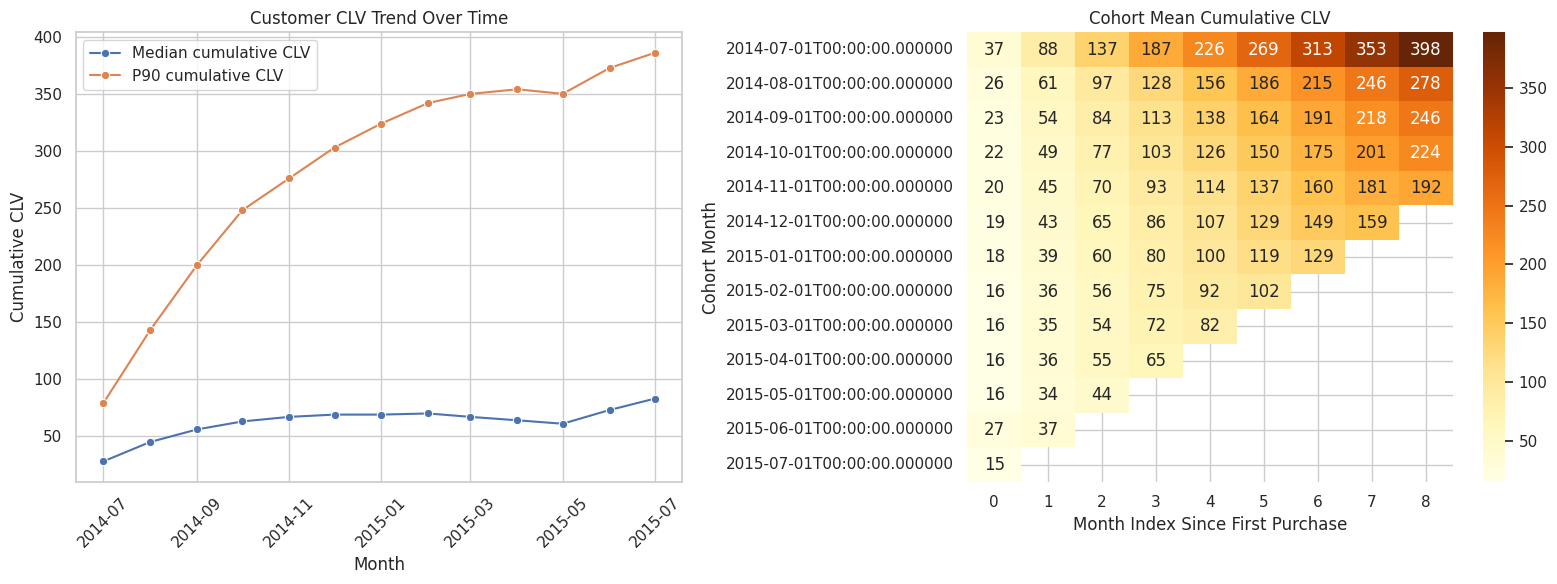

Customer CLV profile summary:


,total_orders,total_spend,avg_order_value,lifetime_days,orders_per_month,estimated_monthly_clv
count,206209.000000,206209.000000,206209.000000,206209.000000,206209.000000,206209.000000
mean,15.590367,157.289396,9.951586,157.222595,2.826441,27.975656
std,16.654774,204.208233,5.863570,103.187341,1.712225,23.802933
min,3.000000,3.000000,1.000000,1.000000,1.111111,1.148936
25%,5.000000,39.000000,5.740741,67.000000,1.750000,12.857143
50%,9.000000,83.000000,8.933333,133.000000,2.357143,21.923077
75%,19.000000,188.000000,13.000000,238.000000,3.312883,35.913978
max,99.000000,3725.000000,70.250000,366.000000,99.000000,1369.285714


Latest CLV trend snapshot:


,order_month,active_customers,avg_monthly_spend,median_cumulative_clv,p90_cumulative_clv
7,2015-02-01,106829,24.613382,70.0,342.0
8,2015-03-01,130879,25.200857,67.0,350.0
9,2015-04-01,158541,23.882989,64.0,354.0
10,2015-05-01,193555,22.952169,61.0,350.0
11,2015-06-01,206185,22.202270,73.0,372.6
12,2015-07-01,206209,10.182621,83.0,386.0


In [8]:
# --- Customer Lifetime Value (CLV) trends ---
CLV_FREQ = "M"  # monthly trend
MAX_MONTH_INDEX = 8  # keep cohort chart readable

if "total_price" not in df.columns:
    raise ValueError("`total_price` column is required for CLV analysis.")

# Build order-level value first to avoid line-level double counting in CLV.
order_value = (
    df.groupby(["user_id", "order_id", "order_date"], observed=False)
    .agg(order_value=("total_price", "sum"))
    .reset_index()
)
order_value["order_month"] = order_value["order_date"].dt.to_period(CLV_FREQ).dt.to_timestamp()

# 1) Customer-level CLV profile
customer_clv = (
    order_value.groupby("user_id", observed=False)
    .agg(
        first_order_date=("order_date", "min"),
        last_order_date=("order_date", "max"),
        total_orders=("order_id", "nunique"),
        total_spend=("order_value", "sum"),
        avg_order_value=("order_value", "mean"),
    )
    .reset_index()
)

customer_clv["lifetime_days"] = (
    customer_clv["last_order_date"] - customer_clv["first_order_date"]
).dt.days + 1
customer_clv["lifetime_months"] = np.maximum(customer_clv["lifetime_days"] / 30.0, 1)
customer_clv["orders_per_month"] = customer_clv["total_orders"] / customer_clv["lifetime_months"]
customer_clv["estimated_monthly_clv"] = customer_clv["avg_order_value"] * customer_clv["orders_per_month"]

# 2) Monthly trend of cumulative CLV per customer
customer_monthly = (
    order_value.groupby(["user_id", "order_month"], observed=False)
    .agg(monthly_spend=("order_value", "sum"))
    .reset_index()
    .sort_values(["user_id", "order_month"])
)
customer_monthly["cumulative_clv"] = customer_monthly.groupby("user_id", observed=False)["monthly_spend"].cumsum()

clv_trend = (
    customer_monthly.groupby("order_month", observed=False)
    .agg(
        active_customers=("user_id", "nunique"),
        avg_monthly_spend=("monthly_spend", "mean"),
        median_cumulative_clv=("cumulative_clv", "median"),
        p90_cumulative_clv=("cumulative_clv", lambda x: x.quantile(0.90)),
    )
    .reset_index()
)

# 3) Cohort CLV progression (by first purchase month)
cohort_base = order_value[["user_id", "order_month"]].drop_duplicates().copy()
cohort_base["cohort_month"] = cohort_base.groupby("user_id", observed=False)["order_month"].transform("min")
cohort_base["month_index"] = (
    cohort_base["order_month"].dt.to_period(CLV_FREQ).astype(int)
    - cohort_base["cohort_month"].dt.to_period(CLV_FREQ).astype(int)
)

cohort_clv = customer_monthly.merge(
    cohort_base[["user_id", "order_month", "cohort_month", "month_index"]],
    on=["user_id", "order_month"],
    how="left",
)

cohort_clv_progress = (
    cohort_clv[cohort_clv["month_index"] <= MAX_MONTH_INDEX]
    .groupby(["cohort_month", "month_index"], observed=False)
    .agg(
        customers=("user_id", "nunique"),
        mean_cumulative_clv=("cumulative_clv", "mean"),
        median_cumulative_clv=("cumulative_clv", "median"),
    )
    .reset_index()
)

cohort_clv_pivot = cohort_clv_progress.pivot(
    index="cohort_month",
    columns="month_index",
    values="mean_cumulative_clv",
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.lineplot(
    data=clv_trend,
    x="order_month",
    y="median_cumulative_clv",
    marker="o",
    label="Median cumulative CLV",
    ax=axes[0],
)
sns.lineplot(
    data=clv_trend,
    x="order_month",
    y="p90_cumulative_clv",
    marker="o",
    label="P90 cumulative CLV",
    ax=axes[0],
)
axes[0].set_title("Customer CLV Trend Over Time")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Cumulative CLV")
axes[0].tick_params(axis="x", rotation=45)

sns.heatmap(cohort_clv_pivot, annot=True, fmt=".0f", cmap="YlOrBr", ax=axes[1])
axes[1].set_title("Cohort Mean Cumulative CLV")
axes[1].set_xlabel("Month Index Since First Purchase")
axes[1].set_ylabel("Cohort Month")

plt.tight_layout()
plt.show()

show_df(
    customer_clv[[
        "total_orders",
        "total_spend",
        "avg_order_value",
        "lifetime_days",
        "orders_per_month",
        "estimated_monthly_clv",
    ]].describe(),
    title="Customer CLV profile summary:",
)
show_df(clv_trend.tail(6), title="Latest CLV trend snapshot:")

if SHOW_VERBOSE_TABLES:
    show_df(cohort_clv_progress.head(20), title="Cohort CLV progression sample:")

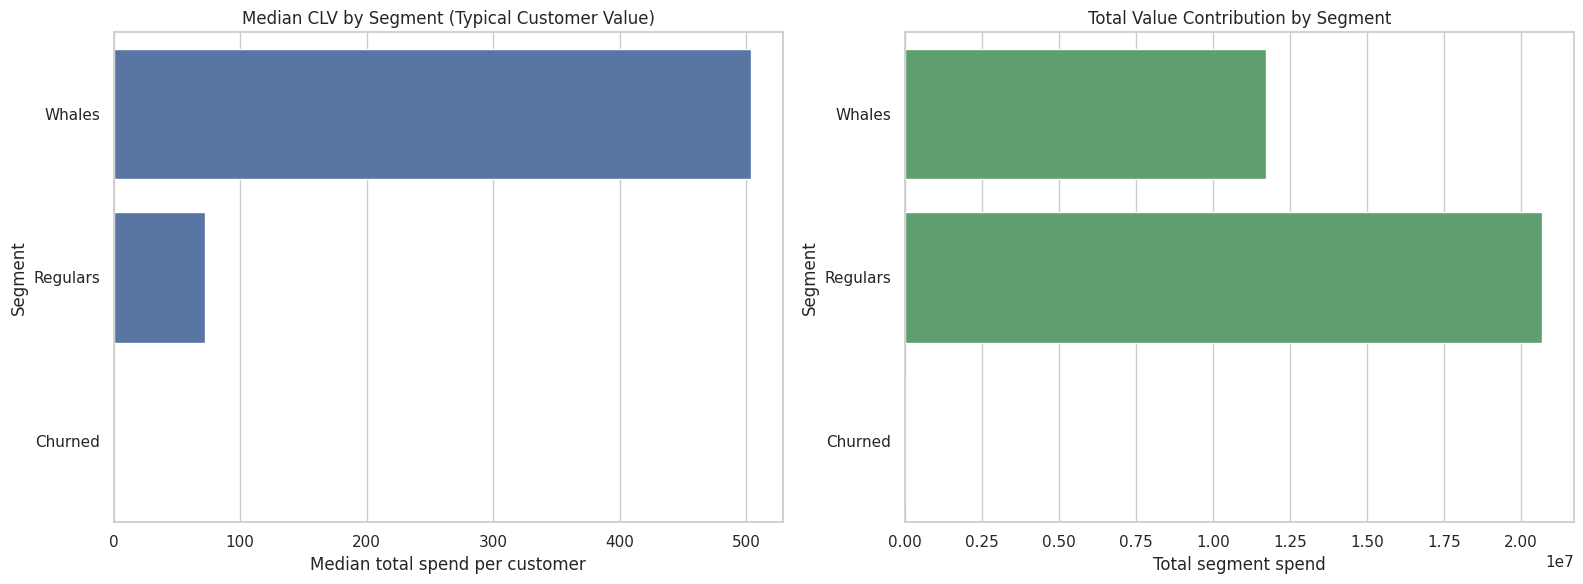

Segment CLV summary:


,segment,customers,median_total_spend,mean_total_spend,median_avg_order_value,median_orders_per_month,median_estimated_monthly_clv,total_segment_spend,segment_share_of_spend,median_latest_cumulative_clv
0,Whales,20644,504.0,568.816751,9.315789,4.684200,47.040113,11742653,0.362042,504.0
1,Regulars,185565,72.0,111.507213,8.863636,2.213115,20.261780,20691836,0.637958,72.0
2,Churned,0,NaN,NaN,NaN,NaN,NaN,0,0.000000,NaN


Top segment by median customer value: Whales (median_total_spend=504.00)
Top segment by total business contribution: Regulars (total_segment_spend=20,691,836.00, share=63.80%)


In [9]:
# --- CLV by segment (median-focused) ---
# Why median: robust to extreme spenders and better reflects a "typical" customer in each segment.

if "segment" not in rfm.columns:
    raise ValueError("`rfm` with `segment` column is required for segment-level CLV analysis.")

# Join customer CLV profile with existing RFM segment labels.
segment_clv_base = customer_clv.merge(
    rfm[["user_id", "segment"]],
    on="user_id",
    how="left",
)
segment_clv_base["segment"] = segment_clv_base["segment"].fillna("Unknown")

segment_clv_summary = (
    segment_clv_base.groupby("segment", observed=False)
    .agg(
        customers=("user_id", "nunique"),
        median_total_spend=("total_spend", "median"),
        mean_total_spend=("total_spend", "mean"),
        median_avg_order_value=("avg_order_value", "median"),
        median_orders_per_month=("orders_per_month", "median"),
        median_estimated_monthly_clv=("estimated_monthly_clv", "median"),
        total_segment_spend=("total_spend", "sum"),
    )
    .reset_index()
)

segment_clv_summary["segment_share_of_spend"] = (
    segment_clv_summary["total_segment_spend"]
    / segment_clv_summary["total_segment_spend"].sum()
)

segment_clv_summary = segment_clv_summary.sort_values(
    ["median_total_spend", "total_segment_spend"],
    ascending=[False, False],
).reset_index(drop=True)

# Latest cumulative CLV per customer (for an alternative median view).
latest_customer_clv = (
    customer_monthly.sort_values(["user_id", "order_month"])
    .groupby("user_id", observed=False)
    .tail(1)[["user_id", "cumulative_clv"]]
)

segment_latest_median = (
    latest_customer_clv.merge(rfm[["user_id", "segment"]], on="user_id", how="left")
    .groupby("segment", observed=False)
    .agg(median_latest_cumulative_clv=("cumulative_clv", "median"))
    .reset_index()
)

segment_clv_summary = segment_clv_summary.merge(
    segment_latest_median,
    on="segment",
    how="left",
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=segment_clv_summary.sort_values("median_total_spend", ascending=False),
    x="median_total_spend",
    y="segment",
    color="#4C72B0",
    ax=axes[0],
)
axes[0].set_title("Median CLV by Segment (Typical Customer Value)")
axes[0].set_xlabel("Median total spend per customer")
axes[0].set_ylabel("Segment")

sns.barplot(
    data=segment_clv_summary.sort_values("total_segment_spend", ascending=False),
    x="total_segment_spend",
    y="segment",
    color="#55A868",
    ax=axes[1],
)
axes[1].set_title("Total Value Contribution by Segment")
axes[1].set_xlabel("Total segment spend")
axes[1].set_ylabel("Segment")

plt.tight_layout()
plt.show()

show_df(segment_clv_summary, title="Segment CLV summary:")

top_median_segment = segment_clv_summary.iloc[0]
top_total_segment = segment_clv_summary.sort_values("total_segment_spend", ascending=False).iloc[0]

print(
    f"Top segment by median customer value: {top_median_segment['segment']} "
    f"(median_total_spend={top_median_segment['median_total_spend']:,.2f})"
)
print(
    f"Top segment by total business contribution: {top_total_segment['segment']} "
    f"(total_segment_spend={top_total_segment['total_segment_spend']:,.2f}, "
    f"share={top_total_segment['segment_share_of_spend']:.2%})"
)

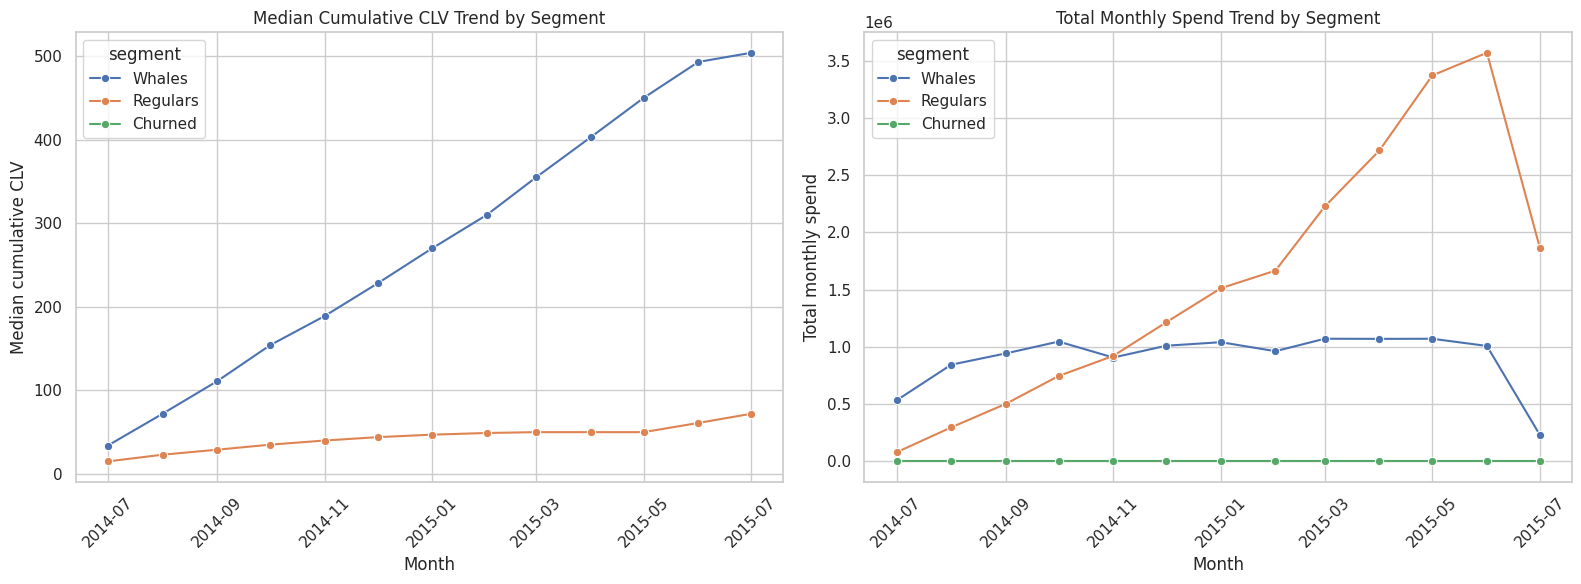

Segment CLV monthly trend snapshot:


,order_month,segment,active_customers,total_monthly_spend,median_monthly_spend,median_cumulative_clv
27,2015-04-01,Whales,20631,1070387,44.0,403.0
28,2015-04-01,Regulars,137910,2716046,14.0,50.0
29,2015-04-01,Churned,0,0,NaN,NaN
30,2015-05-01,Whales,20641,1071304,43.0,450.0
31,2015-05-01,Regulars,172914,3371203,13.0,50.0
32,2015-05-01,Churned,0,0,NaN,NaN
33,2015-06-01,Whales,20644,1008323,40.0,493.0
34,2015-06-01,Regulars,185541,3569452,13.0,61.0
35,2015-06-01,Churned,0,0,NaN,NaN
36,2015-07-01,Whales,20644,231959,9.0,504.0


Pairwise median CLV comparison:


,segment_a,segment_b,n_a,n_b,median_a,median_b,median_diff_a_minus_b,p_value,q_value_bh,significant_5pct
0,Regulars,Whales,185565,20644,72.0,504.0,-432.0,0.0005,0.0005,True


In [10]:
# --- Segment CLV trend over time + median significance checks ---
SEGMENT_CLV_TEST_PERMUTATIONS = 2000
RANDOM_SEED = 42

segment_monthly = customer_monthly.merge(
    rfm[["user_id", "segment"]],
    on="user_id",
    how="left",
)
segment_monthly["segment"] = segment_monthly["segment"].fillna("Unknown")

segment_clv_trend = (
    segment_monthly.groupby(["order_month", "segment"], observed=False)
    .agg(
        active_customers=("user_id", "nunique"),
        total_monthly_spend=("monthly_spend", "sum"),
        median_monthly_spend=("monthly_spend", "median"),
        median_cumulative_clv=("cumulative_clv", "median"),
    )
    .reset_index()
    .sort_values(["order_month", "segment"])
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.lineplot(
    data=segment_clv_trend,
    x="order_month",
    y="median_cumulative_clv",
    hue="segment",
    marker="o",
    ax=axes[0],
)
axes[0].set_title("Median Cumulative CLV Trend by Segment")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Median cumulative CLV")
axes[0].tick_params(axis="x", rotation=45)

sns.lineplot(
    data=segment_clv_trend,
    x="order_month",
    y="total_monthly_spend",
    hue="segment",
    marker="o",
    ax=axes[1],
)
axes[1].set_title("Total Monthly Spend Trend by Segment")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Total monthly spend")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

show_df(segment_clv_trend.tail(12), title="Segment CLV monthly trend snapshot:")


def permutation_test_median_diff(a, b, n_permutations=2000, seed=42):
    """Two-sided permutation test for median difference."""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]

    if len(a) == 0 or len(b) == 0:
        return np.nan, np.nan

    observed = np.median(a) - np.median(b)
    combined = np.concatenate([a, b])
    n_a = len(a)

    rng = np.random.default_rng(seed)
    extreme = 0
    for _ in range(n_permutations):
        permuted = rng.permutation(combined)
        diff = np.median(permuted[:n_a]) - np.median(permuted[n_a:])
        if abs(diff) >= abs(observed):
            extreme += 1

    p_value = (extreme + 1) / (n_permutations + 1)
    return observed, p_value


def benjamini_hochberg(p_values):
    """Return BH-adjusted q-values in original order."""
    p = np.asarray(p_values, dtype=float)
    n = len(p)
    order = np.argsort(p)
    ranked_p = p[order]

    q = np.empty(n, dtype=float)
    prev = 1.0
    for i in range(n - 1, -1, -1):
        rank = i + 1
        val = ranked_p[i] * n / rank
        prev = min(prev, val)
        q[i] = prev

    q = np.clip(q, 0, 1)
    q_original_order = np.empty(n, dtype=float)
    q_original_order[order] = q
    return q_original_order


segment_spend_for_test = segment_clv_base[["segment", "total_spend"]].dropna().copy()
segments = sorted(segment_spend_for_test["segment"].unique())

pairwise_results = []
for i in range(len(segments)):
    for j in range(i + 1, len(segments)):
        seg_a = segments[i]
        seg_b = segments[j]

        spend_a = segment_spend_for_test.loc[
            segment_spend_for_test["segment"] == seg_a,
            "total_spend",
        ]
        spend_b = segment_spend_for_test.loc[
            segment_spend_for_test["segment"] == seg_b,
            "total_spend",
        ]

        median_diff, p_value = permutation_test_median_diff(
            spend_a,
            spend_b,
            n_permutations=SEGMENT_CLV_TEST_PERMUTATIONS,
            seed=RANDOM_SEED,
        )

        pairwise_results.append(
            {
                "segment_a": seg_a,
                "segment_b": seg_b,
                "n_a": int(spend_a.shape[0]),
                "n_b": int(spend_b.shape[0]),
                "median_a": float(np.median(spend_a)),
                "median_b": float(np.median(spend_b)),
                "median_diff_a_minus_b": float(median_diff),
                "p_value": float(p_value),
            }
        )

pairwise_median_test = pd.DataFrame(pairwise_results).sort_values("p_value").reset_index(drop=True)
pairwise_median_test["q_value_bh"] = benjamini_hochberg(pairwise_median_test["p_value"].values)
pairwise_median_test["significant_5pct"] = pairwise_median_test["q_value_bh"] < 0.05

show_df(pairwise_median_test, title="Pairwise median CLV comparison:")

### 6.1 Days Between Orders Distribution by Segment

วิเคราะห์ cadence ของแต่ละ segment ด้วย `days_since_prior_order` แบบ customer-median เพื่อลด noise จาก order รายครั้ง

- Distribution plot: เปรียบเทียบ density ในภาพเดียว
- Box plot: ดู median / IQR / spread ต่อกลุ่ม
- Summary table: customers, median, mean, std, p25, p75

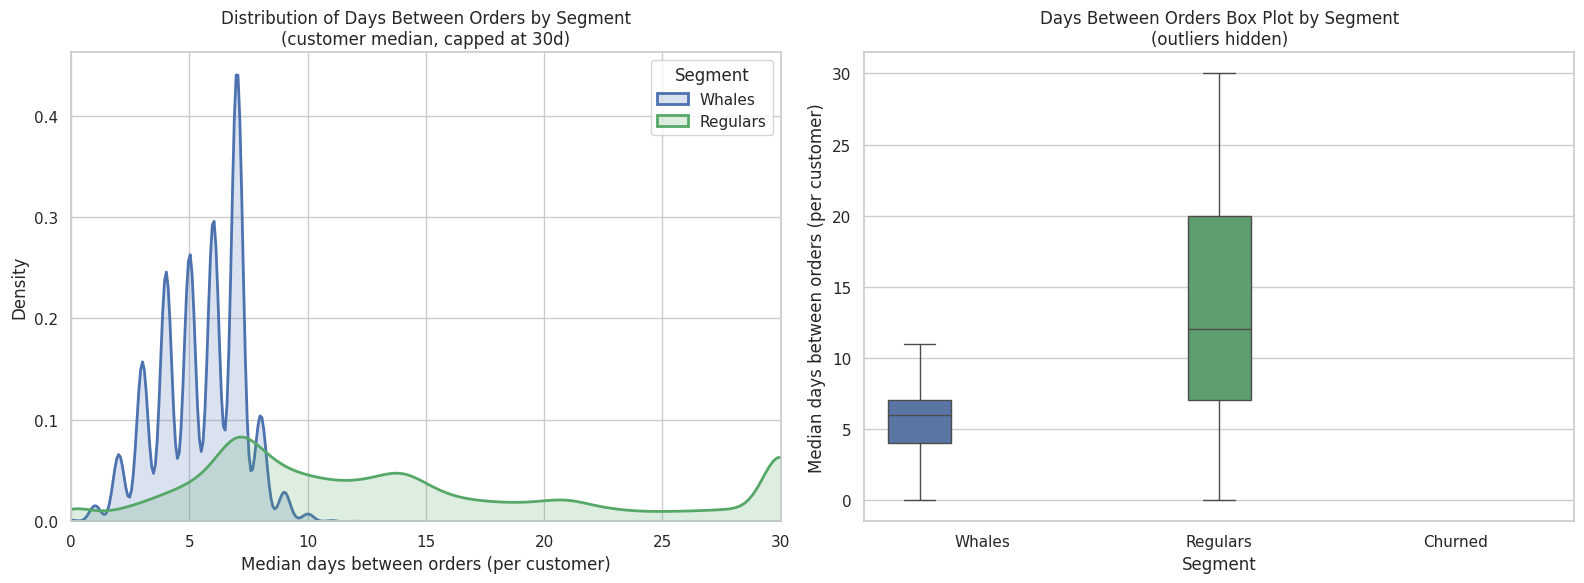

Days between orders summary by segment:


,segment,customers,median,mean,std,p25,p75
0,Whales,20644,6.0,5.514435,1.762523,4.0,7.0
1,Regulars,185565,12.0,13.924940,8.583697,7.0,20.0
2,Churned,0,NaN,NaN,NaN,NaN,NaN



กลุ่มที่สั่งซื้อถี่ที่สุด: Whales (median = 6.0 วัน, IQR = 4.0–7.0)


In [11]:
# --- Days between orders distribution per segment ---
# Use customer-level median to represent each customer's "typical" gap.
# This avoids noise from the first order (NaN days) and large purchase streaks.

days_df = (
    df[df["days_since_prior_order"].notna()]
    .groupby("user_id", observed=False)
    .agg(customer_median_days=("days_since_prior_order", "median"))
    .reset_index()
    .merge(rfm[["user_id", "segment"]], on="user_id", how="left")
)
days_df["segment"] = days_df["segment"].fillna("Unknown")

DAYS_CAP = 30  # cap at 30 for readability; 30d = monthly cadence max
days_plot = days_df.copy()
days_plot["customer_median_days"] = days_plot["customer_median_days"].clip(upper=DAYS_CAP)

SEGMENT_ORDER = ["Whales", "Regulars", "Churned"]
PALETTE = {"Whales": "#4C72B0", "Regulars": "#55A868", "Churned": "#C44E52"}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# KDE distribution via seaborn (no scipy needed)
for seg in SEGMENT_ORDER:
    grp = days_plot[days_plot["segment"] == seg]["customer_median_days"]
    if len(grp) > 1:
        sns.kdeplot(grp, ax=axes[0], label=seg, linewidth=2, color=PALETTE[seg], fill=True, alpha=0.2)

axes[0].set_title("Distribution of Days Between Orders by Segment\n(customer median, capped at 30d)")
axes[0].set_xlabel("Median days between orders (per customer)")
axes[0].set_ylabel("Density")
axes[0].set_xlim(0, DAYS_CAP)
axes[0].legend(title="Segment")

# Box plot — median + spread (outliers hidden for readability)
sns.boxplot(
    data=days_df,
    x="segment",
    y="customer_median_days",
    hue="segment",
    order=SEGMENT_ORDER,
    hue_order=SEGMENT_ORDER,
    palette=PALETTE,
    ax=axes[1],
    showfliers=False,
    legend=False,
)
axes[1].set_title("Days Between Orders Box Plot by Segment\n(outliers hidden)")
axes[1].set_xlabel("Segment")
axes[1].set_ylabel("Median days between orders (per customer)")

plt.tight_layout()
plt.show()

# Summary table
days_summary = (
    days_df.groupby("segment", observed=False)["customer_median_days"]
    .agg(
        customers="count",
        median="median",
        mean="mean",
        std="std",
        p25=lambda x: x.quantile(0.25),
        p75=lambda x: x.quantile(0.75),
    )
    .reset_index()
    .sort_values("median")
    .reset_index(drop=True)
)

show_df(days_summary, title="Days between orders summary by segment:")

top_freq = days_summary.iloc[0]
print(
    f"\nกลุ่มที่สั่งซื้อถี่ที่สุด: {top_freq['segment']} "
    f"(median = {top_freq['median']:.1f} วัน, IQR = {top_freq['p25']:.1f}–{top_freq['p75']:.1f})"
)

### 6.2 Order Funnel (% Customers Reaching Each Order)

วิเคราะห์ drop-off ของลูกค้าตามจำนวน order สะสม

- Funnel bar chart: % ลูกค้าที่มีอย่างน้อย N orders
- Drop-off rate: % ที่หายไประหว่างแต่ละขั้น
- Segment funnel: เปรียบเทียบ Whales / Regulars / Churned

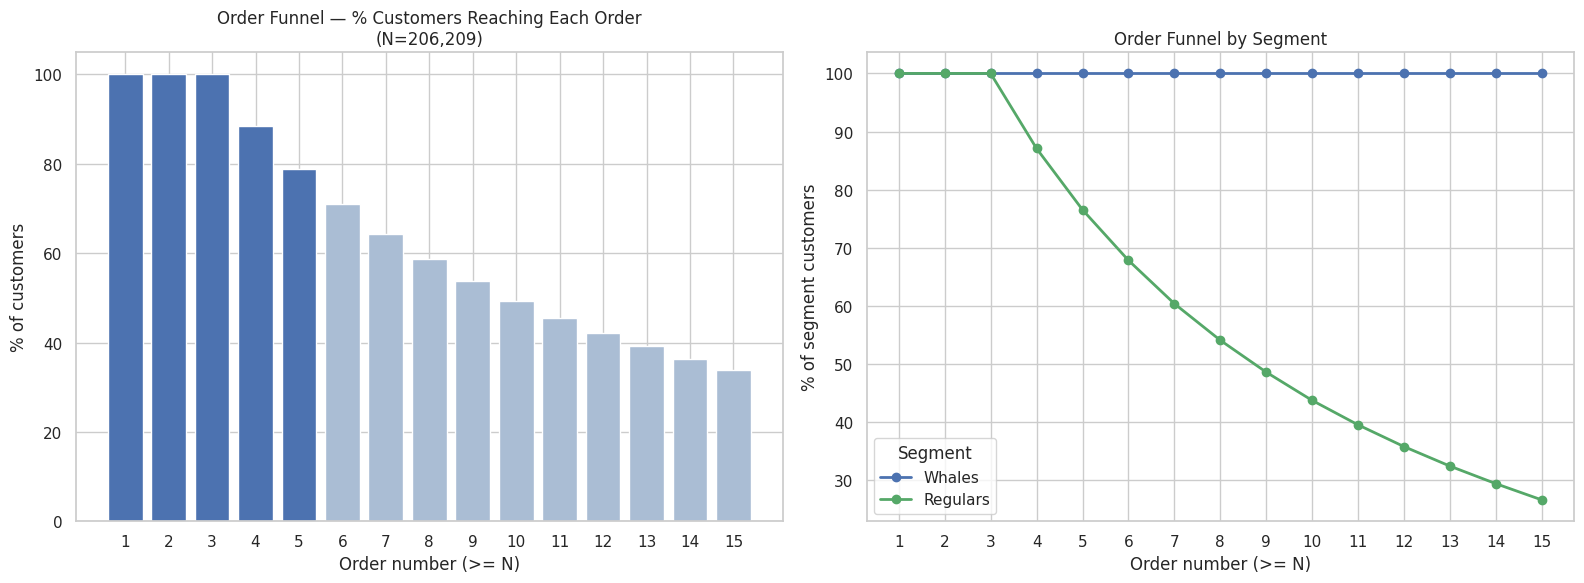

Overall funnel table:


,order_n,customers_reached,pct_of_total,drop_off_pct
0,1,206209,1.000000,0.000000
1,2,206209,1.000000,0.000000
2,3,206209,1.000000,0.116319
3,4,182223,0.883681,0.095001
4,5,162633,0.788680,0.078391
5,6,146468,0.710289,0.067165
6,7,132618,0.643124,0.056739
7,8,120918,0.586386,0.049416
8,9,110728,0.536970,0.043800
9,10,101696,0.493170,0.037898


Big drop-off points (>5%):


,order_n,pct_of_total,drop_off_pct
2,3,1.000000,0.116319
3,4,0.883681,0.095001
4,5,0.788680,0.078391
5,6,0.710289,0.067165
6,7,0.643124,0.056739


In [12]:
# --- Order Funnel ---
FUNNEL_MAX_ORDER = 15  # show up to order #15

# Customer max order number (total_orders per customer)
user_max_order = (
    df.groupby("user_id", observed=False)["order_number"]
    .max()
    .reset_index()
    .rename(columns={"order_number": "max_order"})
    .merge(rfm[["user_id", "segment"]], on="user_id", how="left")
)
user_max_order["segment"] = user_max_order["segment"].fillna("Unknown")

total_customers = user_max_order["user_id"].nunique()

# Overall funnel: % of customers with max_order >= n
funnel_steps = range(1, FUNNEL_MAX_ORDER + 1)
funnel = pd.DataFrame(
    {
        "order_n": list(funnel_steps),
        "customers_reached": [
            (user_max_order["max_order"] >= n).sum() for n in funnel_steps
        ],
    }
)
funnel["pct_of_total"] = funnel["customers_reached"] / total_customers
funnel["drop_off_pct"] = funnel["pct_of_total"].diff(-1).clip(lower=0)

# Segment funnel
seg_funnel_rows = []
for seg in SEGMENT_ORDER + ["Unknown"]:
    seg_users = user_max_order[user_max_order["segment"] == seg]
    n_seg = len(seg_users)
    if n_seg == 0:
        continue
    for n in funnel_steps:
        seg_funnel_rows.append(
            {
                "segment": seg,
                "order_n": n,
                "pct_reached": (seg_users["max_order"] >= n).sum() / n_seg,
            }
        )
seg_funnel = pd.DataFrame(seg_funnel_rows)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Overall funnel bar chart
bar_colors = ["#4C72B0" if n <= 5 else "#AABDD4" for n in funnel["order_n"]]
axes[0].bar(funnel["order_n"], funnel["pct_of_total"] * 100, color=bar_colors, edgecolor="white")
axes[0].set_title(f"Order Funnel — % Customers Reaching Each Order\n(N={total_customers:,})")
axes[0].set_xlabel("Order number (>= N)")
axes[0].set_ylabel("% of customers")
axes[0].set_xticks(list(funnel_steps))

# Segment funnel line chart
seg_palette = dict(zip(SEGMENT_ORDER, ["#4C72B0", "#55A868", "#C44E52"]))
for seg in SEGMENT_ORDER:
    seg_data = seg_funnel[seg_funnel["segment"] == seg]
    if not seg_data.empty:
        axes[1].plot(
            seg_data["order_n"],
            seg_data["pct_reached"] * 100,
            marker="o",
            label=seg,
            color=seg_palette.get(seg),
            linewidth=2,
        )
axes[1].set_title("Order Funnel by Segment")
axes[1].set_xlabel("Order number (>= N)")
axes[1].set_ylabel("% of segment customers")
axes[1].set_xticks(list(funnel_steps))
axes[1].legend(title="Segment")

plt.tight_layout()
plt.show()

show_df(funnel, title="Overall funnel table:")

# Key drop-off points (drop > 5%)
big_drops = funnel[funnel["drop_off_pct"] > 0.05].copy()
show_df(big_drops[["order_n", "pct_of_total", "drop_off_pct"]], title="Big drop-off points (>5%):")

### 6.3 First Purchase Category (Gateway Category)

หา "gateway category" ที่พาลูกค้าใหม่เข้าสู่การเป็น Whales

- Top departments/aisles ในออร์เดอร์แรก (`order_number = 1`)
- เปรียบเทียบตาม segment
- Conversion insight: gateway category ไหนมีสัดส่วนกลายเป็น Whales สูง

In [ ]:
# --- First Purchase Category ---
TOP_N_GATEWAY = 10
GATEWAY_COL = "department"  # switch to "aisle" for finer granularity

first_order_df = df[df["order_number"] == 1].copy()

# Ensure department column exists
if GATEWAY_COL not in first_order_df.columns:
    product_dim_gw = data_access_module.load_product_dimension(
        use_sample=USE_SAMPLE, project_root=PROJECT_ROOT
    )[["product_id", GATEWAY_COL]]
    first_order_df = first_order_df.merge(product_dim_gw, on="product_id", how="left")

first_order_df[GATEWAY_COL] = first_order_df[GATEWAY_COL].fillna("Unknown")

# 1) Overall top gateway categories
gateway_overall = (
    first_order_df.groupby(GATEWAY_COL, observed=False)
    .agg(customers=("user_id", "nunique"), order_lines=("product_id", "count"))
    .reset_index()
    .sort_values("customers", ascending=False)
    .head(TOP_N_GATEWAY)
    .reset_index(drop=True)
)
gateway_overall["pct_of_new_customers"] = (
    gateway_overall["customers"] / first_order_df["user_id"].nunique()
)

# 2) Gateway by segment — which category did each segment start with?
first_order_seg = first_order_df.merge(rfm[["user_id", "segment"]], on="user_id", how="left")
first_order_seg["segment"] = first_order_seg["segment"].fillna("Unknown")

gateway_by_segment = (
    first_order_seg.groupby(["segment", GATEWAY_COL], observed=False)
    .agg(customers=("user_id", "nunique"))
    .reset_index()
)
seg_totals = gateway_by_segment.groupby("segment", observed=False)["customers"].transform("sum")
gateway_by_segment["pct_in_segment"] = gateway_by_segment["customers"] / seg_totals

top_gateway_by_segment = (
    gateway_by_segment.sort_values(["segment", "customers"], ascending=[True, False])
    .groupby("segment", observed=False)
    .head(TOP_N_GATEWAY)
    .reset_index(drop=True)
)

# 3) Conversion: for each gateway category, what % ended up as Whales?
whales_first = (
    first_order_seg.groupby([GATEWAY_COL, "segment"], observed=False)
    .agg(customers=("user_id", "nunique"))
    .reset_index()
)
cat_totals = whales_first.groupby(GATEWAY_COL, observed=False)["customers"].transform("sum")
whales_first["pct_in_cat"] = whales_first["customers"] / cat_totals

whale_conversion = (
    whales_first[whales_first["segment"] == "Whales"]
    [[GATEWAY_COL, "pct_in_cat"]]
    .rename(columns={"pct_in_cat": "whale_conversion_rate"})
    .sort_values("whale_conversion_rate", ascending=False)
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(
    data=gateway_overall,
    x="customers",
    y=GATEWAY_COL,
    color="#4C72B0",
    ax=axes[0],
)
axes[0].set_title(f"Top {TOP_N_GATEWAY} Gateway Categories\n(first order, by unique customers)")
axes[0].set_xlabel("Unique customers")
axes[0].set_ylabel(GATEWAY_COL.title())

# Whales conversion rate by gateway category (top 10)
top_whale_conv = whale_conversion.head(TOP_N_GATEWAY)
sns.barplot(
    data=top_whale_conv,
    x="whale_conversion_rate",
    y=GATEWAY_COL,
    color="#55A868",
    ax=axes[1],
)
axes[1].set_title(f"Whales Conversion Rate by Gateway Category\n(% of first-time buyers who became Whales)")
axes[1].set_xlabel("% who became Whales")
axes[1].set_ylabel(GATEWAY_COL.title())
axes[1].set_xlim(0, top_whale_conv["whale_conversion_rate"].max() * 1.2)

plt.tight_layout()
plt.show()

show_df(gateway_overall, title=f"Overall top gateway categories ({GATEWAY_COL}):")
show_df(top_gateway_by_segment, title="Top gateway categories by segment:")
show_df(whale_conversion, title="Whales conversion rate by gateway category:")

KeyError: 'segment'

: 

## 7) Trend Deep Dive (User & Product)

In [ ]:
# --- User trend + Product trend (Top N + Share) ---
TREND_FREQ = "W"  # use "M" for monthly
TOP_N_PRODUCTS = 8
TOP_N_DEPARTMENTS = 6

trend_df = df.copy()
trend_df["period"] = trend_df["order_date"].dt.to_period(TREND_FREQ).dt.to_timestamp()

# User trend metrics
user_trend = (
    trend_df.groupby("period", observed=False)
    .agg(
        active_users=("user_id", "nunique"),
        orders=("order_id", "nunique"),
        order_lines=("product_id", "count"),
        reorder_rate=("reordered", "mean"),
    )
    .reset_index()
)
user_trend["orders_per_active_user"] = user_trend["orders"] / user_trend["active_users"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.lineplot(data=user_trend, x="period", y="active_users", marker="o", ax=axes[0], label="active_users")
sns.lineplot(data=user_trend, x="period", y="orders_per_active_user", marker="o", ax=axes[0], label="orders_per_active_user")
axes[0].set_title(f"User Trend ({TREND_FREQ})")
axes[0].set_xlabel("Period")
axes[0].set_ylabel("Count / Ratio")
axes[0].tick_params(axis="x", rotation=45)

sns.lineplot(data=user_trend, x="period", y="reorder_rate", marker="o", ax=axes[1], color="#C44E52")
axes[1].set_title(f"Reorder Rate Trend ({TREND_FREQ})")
axes[1].set_xlabel("Period")
axes[1].set_ylabel("Reorder Rate")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

show_df(user_trend, title="User trend summary:")

# Product trend prep: ensure department exists
if "department" not in trend_df.columns:
    product_dim = data_access_module.load_product_dimension(
        use_sample=USE_SAMPLE,
        project_root=PROJECT_ROOT,
    )[["product_id", "department"]]
    trend_df = trend_df.merge(product_dim, on="product_id", how="left")

period_total_lines = (
    trend_df.groupby("period", observed=False)
    .size()
    .rename("total_lines_period")
    .reset_index()
)

# Top N products by overall order lines
top_products = (
    trend_df["product_name"].value_counts().head(TOP_N_PRODUCTS).index.tolist()
)
product_period = (
    trend_df[trend_df["product_name"].isin(top_products)]
    .groupby(["period", "product_name"], observed=False)
    .size()
    .rename("order_lines")
    .reset_index()
    .merge(period_total_lines, on="period", how="left")
)
product_period["share_of_total"] = product_period["order_lines"] / product_period["total_lines_period"]

# Top N departments by overall order lines
top_departments = (
    trend_df["department"].dropna().value_counts().head(TOP_N_DEPARTMENTS).index.tolist()
)
dept_period = (
    trend_df[trend_df["department"].isin(top_departments)]
    .groupby(["period", "department"], observed=False)
    .size()
    .rename("order_lines")
    .reset_index()
    .merge(period_total_lines, on="period", how="left")
)
dept_period["share_of_total"] = dept_period["order_lines"] / dept_period["total_lines_period"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sns.lineplot(
    data=product_period,
    x="period",
    y="order_lines",
    hue="product_name",
    marker="o",
    ax=axes[0, 0],
)
axes[0, 0].set_title(f"Top {TOP_N_PRODUCTS} Products: Order Lines Trend ({TREND_FREQ})")
axes[0, 0].set_xlabel("Period")
axes[0, 0].set_ylabel("Order lines")
axes[0, 0].tick_params(axis="x", rotation=45)

sns.lineplot(
    data=product_period,
    x="period",
    y="share_of_total",
    hue="product_name",
    marker="o",
    ax=axes[0, 1],
)
axes[0, 1].set_title(f"Top {TOP_N_PRODUCTS} Products: Share of Total ({TREND_FREQ})")
axes[0, 1].set_xlabel("Period")
axes[0, 1].set_ylabel("Share of total")
axes[0, 1].set_ylim(0, 1)
axes[0, 1].tick_params(axis="x", rotation=45)

sns.lineplot(
    data=dept_period,
    x="period",
    y="order_lines",
    hue="department",
    marker="o",
    ax=axes[1, 0],
)
axes[1, 0].set_title(f"Top {TOP_N_DEPARTMENTS} Departments: Order Lines Trend ({TREND_FREQ})")
axes[1, 0].set_xlabel("Period")
axes[1, 0].set_ylabel("Order lines")
axes[1, 0].tick_params(axis="x", rotation=45)

sns.lineplot(
    data=dept_period,
    x="period",
    y="share_of_total",
    hue="department",
    marker="o",
    ax=axes[1, 1],
)
axes[1, 1].set_title(f"Top {TOP_N_DEPARTMENTS} Departments: Share of Total ({TREND_FREQ})")
axes[1, 1].set_xlabel("Period")
axes[1, 1].set_ylabel("Share of total")
axes[1, 1].set_ylim(0, 1)
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

show_df(product_period.sort_values(["product_name", "period"]), title="Product trend sample:")
show_df(dept_period.sort_values(["department", "period"]), title="Department trend sample:")

## 8) Distribution Diagnostics (Histogram Supplements)

ใช้ histogram เพื่ออ่าน shape ของการกระจาย (ไม่ใช่ time trend)
- `days_since_prior_order`
- `orders_per_user`
- `product_growth_rate` ข้ามช่วงเวลา

In [ ]:
# --- Histogram supplements ---

# 1) Distribution of days_since_prior_order
days_dist = df["days_since_prior_order"].dropna()

# 2) Distribution of order frequency per user
user_order_freq = (
    df.groupby("user_id", observed=False)["order_id"]
    .nunique()
    .rename("orders_per_user")
)

# 3) Distribution of product growth rate between periods
growth_base = (
    trend_df.groupby(["period", "product_name"], observed=False)
    .size()
    .rename("order_lines")
    .reset_index()
)
growth_base = growth_base.sort_values(["product_name", "period"])
growth_base["product_growth_rate"] = growth_base.groupby("product_name", observed=False)["order_lines"].pct_change()

# Keep finite growth values for histogram
growth_values = growth_base["product_growth_rate"].replace([np.inf, -np.inf], np.nan).dropna()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(days_dist, bins=20, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution: days_since_prior_order")
axes[0].set_xlabel("Days since prior order")
axes[0].set_ylabel("Frequency")

sns.histplot(user_order_freq, bins=20, kde=True, ax=axes[1], color="#55A868")
axes[1].set_title("Distribution: orders per user")
axes[1].set_xlabel("Orders per user")
axes[1].set_ylabel("Frequency")

sns.histplot(growth_values, bins=20, kde=True, ax=axes[2], color="#C44E52")
axes[2].set_title(f"Distribution: product growth rate ({TREND_FREQ})")
axes[2].set_xlabel("Growth rate (period-over-period)")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

show_df(user_order_freq.describe().to_frame(name="orders_per_user"), title="orders_per_user summary:")
show_df(growth_values.describe().to_frame(name="product_growth_rate"), title="product_growth_rate summary:")

# --- Executive summary block (auto-refresh after re-run) ---
segment_snapshot = (
    rfm.groupby("segment", observed=False)
    .agg(
        users=("user_id", "nunique"),
        median_total_orders=("total_orders", "median"),
        median_reorder_ratio=("reorder_ratio", "median"),
        median_days_since_last_order=("days_since_last_order", "median"),
    )
    .reset_index()
)
segment_snapshot["user_share"] = segment_snapshot["users"] / segment_snapshot["users"].sum()

print("\n=== Executive Summary (Quick Read) ===")
print(f"Data mode: {'SAMPLE' if USE_SAMPLE else 'FULL DATASET'}")
print(f"Rows: {len(df):,} | Users: {df['user_id'].nunique():,} | Orders: {df['order_id'].nunique():,}")
print(f"Date range: {df['order_date'].min().date()} -> {df['order_date'].max().date()}")
show_df(segment_snapshot, title="Segment snapshot:")

top5 = df["product_name"].value_counts().head(5).rename("order_lines").to_frame()
show_df(top5, title="Top 5 products overall (order lines):")

print("Overall reorder rate:", f"{df['reordered'].mean():.2%}")
print("Median days_since_prior_order:", f"{df['days_since_prior_order'].median():.1f}")

## 9) Executive Summary (Interpretation Template)

ใช้ checklist นี้ตอนสรุปผลประชุม/พรีเซนต์

- Segment story: Whales / Regulars / Churned ต่างกันที่อะไร (order frequency, reorder, recency)
- Time-slot story: วันและชั่วโมงไหนมีทั้ง volume และ reorder สูง
- Category story: หมวดไหน repeat สูง และหมวดไหนมูลค่าตะกร้าสูง
- Risk story: threshold churn ที่เหมาะกับธุรกิจ และ segment ไหนเสี่ยงสุด
- Action story: แผนที่ควรทำทันที 3 อย่าง (retain Whales, grow Regulars, win-back Churned)

หมายเหตุ: ให้รัน cell summary ก่อนหน้าเพื่ออัปเดตตัวเลขล่าสุดทุกครั้ง